Processed images/tomato_unripe/image0.bmp
Processed images/tomato_unripe/image1.bmp
Processed images/tomato_unripe/image2.bmp
Processed images/tomato_unripe/image3.bmp
Processed images/tomato_unripe/image4.bmp
Processed images/tomato_unripe/image5.bmp
Processed images/tomato_unripe/image6.bmp
Processed images/tomato_unripe/image7.bmp
Processed images/tomato_unripe/image8.bmp
Processed images/tomato_unripe/image9.bmp
Processed images/tomato_overripe/image0.bmp
Processed images/tomato_overripe/image1.bmp
Processed images/tomato_overripe/image2.bmp
Processed images/tomato_overripe/image3.bmp
Processed images/tomato_overripe/image4.bmp
Processed images/tomato_overripe/image5.bmp
Processed images/tomato_overripe/image6.bmp
Processed images/tomato_overripe/image7.bmp
Processed images/tomato_overripe/image8.bmp
Processed images/tomato_overripe/image9.bmp
Exported to fruit_feature_dataset.csv
tomato_unripe image 0
images/tomato_unripe/image0.bmp
Query features from image: [1.83713463e-01 1.107

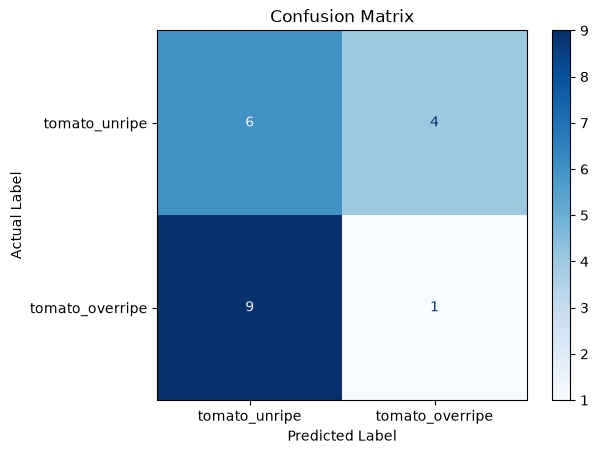

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# -----------------------------------------------------------
def resize_nearest(img, new_h, new_w):
    old_h, old_w = img.shape[:2]
    row_idx = (np.linspace(0, old_h - 1, new_h)).astype(int)
    col_idx = (np.linspace(0, old_w - 1, new_w)).astype(int)
    # meshgrid for all pairs of row,col
    grid_y, grid_x = np.meshgrid(row_idx, col_idx, indexing='ij')
    # get the image at those coordinates
    return img[grid_y, grid_x]
# -----------------------------------------------------------
def compute_Roundness(mask):
    # Assume 'mask' is your binary object mask (dtype=bool or 0/1, shape (H,W)), where object=True/1
    # 1. Compute area
    area = np.sum(mask)

    # 2. Compute perimeter (Numpy only, 4-connectivity)
    # A pixel is counted as perimeter if it is object and has at least one neighbor that is background
    # Pad the mask to handle edges
    padded = np.pad(mask, pad_width=1, mode='constant', constant_values=0)

    # Get 4-connected neighbors
    neighbors = (
        ~padded[1:-1, 1:-1] &  # Not object itself (should not count pure background)
        (
            padded[:-2, 1:-1]   |  # above
            padded[2:, 1:-1]    |  # below
            padded[1:-1, :-2]   |  # left
            padded[1:-1, 2:]       # right
        )
    )
    # Now, perimeter mask: those pixels that are object and have at least one neighbor that's background
    perimeter_mask = (
        mask &
        (
            (~padded[:-2, 1:-1]) |
            (~padded[2:, 1:-1])  |
            (~padded[1:-1, :-2]) |
            (~padded[1:-1, 2:])
        )
    )
    perimeter = np.sum(perimeter_mask)

    # 3. Compute roundness
    if perimeter > 0:
        roundness = 4 * np.pi * area / (perimeter ** 2)
    else:
        roundness = 0

##    print(f"Area: {area}")
##    print(f"Perimeter: {perimeter}")
##    print(f"Roundness: {roundness:.4f}")
    return roundness

# ---------------------------------------------------------------------------------------------
def compute_Elongation(mask):
    # Assume mask is your binary mask (bool/0-1), True for object pixels
    ys, xs = np.where(mask)  # Object pixel coordinates

    # Stack as (N, 2) array
    coords = np.column_stack((xs, ys))

    # Compute covariance matrix of coordinates
    cov = np.cov(coords, rowvar=False)

    # Compute eigenvalues (variances along principal axes)
    eigvals = np.linalg.eigvalsh(cov)  # Returns sorted eigenvalues

    # Major and minor axes (standard deviations)
    if eigvals[0] > 0:
        elongation = np.sqrt(eigvals[1]) / np.sqrt(eigvals[0])
    else:
        elongation = np.inf

##    print(f"Eigenvalues: {eigvals}")
##    print(f"Elongation: {elongation:.3f}")
    return elongation
# ---------------------------------------------------------------------------------------------
def FeatureExtraction(img_raw):
    #img_raw = plt.imread('image0.png')  # Loads with shape (H,W,3) or (H,W,4)
    if img_raw.dtype != np.uint8:
        img_raw = (img_raw * 255).astype(np.uint8)

    # Remove alpha channel if present
    if img_raw.shape[2] == 4:
        img_raw = img_raw[:, :, :3]

    img = resize_nearest(img_raw, 200, 200)    

    # Convert to grayscale
    gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

    # Otsu's threshold (NumPy implementation)
    hist, bin_edges = np.histogram(gray.ravel(), bins=256, range=(0, 256))
    total = gray.size
    current_max, threshold = 0, 0
    sum_total = np.dot(np.arange(256), hist)
    sum_background, weight_background = 0.0, 0.0

    for i in range(256):
        weight_background += hist[i]
        if weight_background == 0:
            continue
        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break
        sum_background += i * hist[i]
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        between_var = (weight_background * weight_foreground *
                       (mean_background - mean_foreground) ** 2)
        if between_var > current_max:
            current_max = between_var
            threshold = i

    # Apply Otsu threshold
    mask = gray < threshold
    # ---------------------------------------------
    roundness = compute_Roundness(mask)
    #print(f"Roundness: {roundness:.4f}")

    elongation = compute_Elongation(mask)
    #print(f"Elongation: {elongation:.4f}")
    # ---------------------------------------------
    # Create binarized image: white (255) for object, black (0) for background
    binary_mask = np.zeros_like(gray, dtype=np.uint8)
    binary_mask[mask] = 255
    # ---------------------------------------------
    # Apply mask to color image, set background to black
    result = np.zeros_like(img)
    result[mask] = img[mask]

    object_pixels = img[mask]           # Shape: (N_object_pixels, 3)
    if object_pixels.size > 0:
        avg_r, avg_g, avg_b = object_pixels.mean(axis=0)       
    else:
        avg_r, avg_g, avg_b = -1, -1, -1

    
    featureVector = np.array([roundness, elongation, avg_r, avg_g, avg_b])
    return featureVector
# ---------------------------------------------------------------------------------------------   
def CreateDataset(ImgeNum = 10):
    class_folders = ['tomato_unripe', 'tomato_overripe']
    n_images = ImgeNum   # Number of images per folder

    dataset = []

    for class_name in class_folders:    
        for i in range(n_images):       
            img_path = 'images/' + class_name +  '/image' + str(i) + '.bmp'        
            try:
                img_raw = plt.imread(img_path)
                feature_vec = FeatureExtraction(img_raw)
                # Combine features and label as last column
                row = feature_vec.tolist() + [class_name]
                dataset.append(row)
                print(f"Processed {img_path}")
            except Exception as e:
                print(f"Failed {img_path}: {e}")

    # Create DataFrame and export to CSV
    columns = ['Roundness', 'Elongation', 'Avg_R', 'Avg_G', 'Avg_B', 'Label']
    df = pd.DataFrame(dataset, columns=columns)
    df.to_csv('fruit_feature_dataset.csv', index=False)
    print("Exported to fruit_feature_dataset.csv")
# ------------------------------------------------------------------------
# ------------------------------------------------------------------------
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * \
           np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

class NaiveBayesClassifier:
    def __init__(self, _DataLoc, _ClassName):
        self.DataLoc = _DataLoc
        self.ClassName = _ClassName

    def compute_posterior_probability(self, queried_x):
        df = pd.read_csv(self.DataLoc)
        X = df.iloc[:, :-1].to_numpy(dtype=float)
        y = df.iloc[:, -1].to_numpy(str)
        N = y.size
        class_labels = np.unique(y)
        posterior_probs = []
        for c in class_labels:
            P_c = np.sum(y == c) / N  # Prior for class c
            indices = np.where(y == c)[0]
            likelihood = 1.0
            for i in range(len(queried_x)):
                mu = np.mean(X[indices, i])
                sigma = np.std(X[indices, i])
                sigma = sigma if sigma > 0 else 1e-6
                prob = normal_pdf(queried_x[i], mu, sigma)
                likelihood *= prob
            posterior_probs.append(P_c * likelihood)
        posterior_probs = np.array(posterior_probs)
        total = np.sum(posterior_probs)
        if total == 0:
            posterior_probs = np.zeros_like(posterior_probs)
        else:
            posterior_probs = posterior_probs / total
        return posterior_probs

    def Plot_posterior_probability(self, posterior_probs):
        plt.bar(self.ClassName, posterior_probs, color=['blue','orange', 'purple'])
        plt.xlabel('Class')
        plt.ylabel('Posterior Probability')
        plt.title('Posterior Probability for Each Class')
        plt.ylim(0, 1.2)
        for i, v in enumerate(posterior_probs):
            plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)
        plt.show()
# ------------------------------------------------------------------------
def PredictSingleImage():
    CreateDataset(ImgeNum = 10)

    test_img_path = 'images/' + 'tomato_unripe/image9.bmp'  # or any real image path

    img_raw = plt.imread(test_img_path)
    query = FeatureExtraction(img_raw)  # This returns the feature vector

    print("Query features from image:", query)

    # Classification
    class_names = ['tomato_unripe', 'tomato_overripe']
    classifier = NaiveBayesClassifier('fruit_feature_dataset.csv', class_names)
    probs = classifier.compute_posterior_probability(query)
    print("Posterior probabilities:", probs)

    # Plot image and probability bar chart side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Show input image
    axes[0].imshow(img_raw)
    axes[0].axis('off')
    axes[0].set_title('Input Image')

    # Show bar plot of probabilities
    bars = axes[1].bar(class_names, probs, color=['blue','orange','purple'])
    axes[1].set_ylim(0, 1.2)
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Posterior Probability")
    axes[1].set_title("Class Probabilities")
    for i, v in enumerate(probs):
        axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)

    plt.tight_layout()
    plt.show()
# ------------------------------------------------------------------------
def PredictMultipleImages():
    ImgeNum = 10
    CreateDataset(ImgeNum)
    class_names = ['tomato_unripe', 'tomato_overripe']

    Actual_Label_All = []
    Predicted_Label_All = []

    for c_n in class_names:
        Actual_Label = c_n        
        for i in range(ImgeNum):
            Actual_Label_All.append(Actual_Label)
            print(c_n + ' ' + 'image' + ' ' + str(i))
            train_img_path_i = 'images/' +  c_n + '/image' + str(i)  + '.bmp'       
            print(train_img_path_i)
            img_raw = plt.imread(train_img_path_i)
            query = FeatureExtraction(img_raw)  # This returns the feature vector
            print("Query features from image:", query)
            # Classification    
            classifier = NaiveBayesClassifier('fruit_feature_dataset.csv', class_names)
            probs = classifier.compute_posterior_probability(query)
            print("Posterior probabilities:", probs)
            Predicted_Label_Index = np.argmax(probs)
            Predicted_Label = class_names[Predicted_Label_Index]
            Predicted_Label_All.append(Predicted_Label)
   
    Actual_Label_All_np = np.array(Actual_Label_All)
    Predicted_Label_All_np = np.array(Predicted_Label_All)
    Results = np.column_stack((Actual_Label_All_np, Predicted_Label_All_np))
    print('Results ', Results)
    
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Calculate the confusion matrix
    cm = confusion_matrix(Actual_Label_All_np, Predicted_Label_All_np, labels=class_names)

    tn, fp, fn, tp = cm.ravel()
    #  true negative (tn), false positive (fp), false negative (fn), and true positive (tp) value
    print('true negative (tn) = ', tn)
    print('false negative (fn) = ', fn)
    print('true positive (tp) = ', tp)
    print('false positive (fp) = ', fp)   
    
    
    # Plot the confusion matrix with labeled axes
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()    
# -----------------------------
# -------------------------------------------
PredictMultipleImages()    
